In [1]:
import fastf1
import pandas as pd
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

/Users/chethanjujjavarapu/Desktop/GitHub/kyrios/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Load 2023 Japan Grand Prix for Understanding

In [2]:
# Enable caching to speed up data loading (optional but recommended)
# Cache directory will be created automatically in the scripts directory
if '__file__' in globals():
    # Running as a script
    file_path = os.path.abspath(__file__)
    scripts_dir = os.path.dirname(file_path)
    cache_dir = os.path.join(scripts_dir, 'cache')
else:
    # Running in IPython/interactive mode - use current working directory
    cache_dir = os.path.join(os.getcwd(), 'cache')

# Create cache directory if it doesn't exist
os.makedirs(cache_dir, exist_ok=True)
fastf1.Cache.enable_cache(cache_dir)

# Load a session (example: 2023 Bahrain Grand Prix, Race)
year = 2023
gp = 'Japan'
session_type = 'R'  # R = Race, Q = Qualifying, FP1/FP2/FP3 = Practice

session = fastf1.get_session(year, gp, session_type)
session.load()  # Load all available data for this session

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 00:00.076000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '44', '55', '63', '14', '31', '10', '40', '2

In [3]:
session.track_status

,Time,Status,Message
0,0 days 00:00:47.740000,1,AllClear
1,0 days 01:03:30.609000,2,Yellow
2,0 days 01:03:36.406000,1,AllClear
3,0 days 01:04:16.546000,4,SCDeployed
4,0 days 01:12:55.099000,1,AllClear
5,0 days 01:26:14.398000,2,Yellow
6,0 days 01:26:33.710000,1,AllClear
7,0 days 01:28:32.895000,6,VSCDeployed
8,0 days 01:29:34.785000,7,VSCEnding
9,0 days 01:29:49.738000,1,AllClear


## Understanding session.track_status

`session.track_status` is a **DataFrame** containing track status changes throughout the session. This tracks flags, safety car deployments, and other track condition changes that can significantly impact race strategy and lap times.

### What it contains:
- Track status changes with timestamps
- Flag conditions (Green, Yellow, Red)
- Safety Car (SC) deployments
- Virtual Safety Car (VSC) periods
- All clear conditions

### Key Use Cases:
- Identifying periods where lap times are invalid or slowed due to flags/SC
- Understanding race interruptions and their impact
- Filtering out laps affected by safety car periods for fair performance comparison
- Analyzing how track conditions changed throughout the session


In [4]:
# Basic info about the track_status DataFrame
print("=== TRACK STATUS STRUCTURE ===")
print(f"Type: {type(session.track_status)}")
print(f"Shape: {session.track_status.shape}")
print(f"Number of status changes: {len(session.track_status)}")
print(f"\nColumns: {list(session.track_status.columns)}")
print(f"\nIndex: {session.track_status.index.name if session.track_status.index.name else 'Default Index'}")
print(f"\nData types:\n{session.track_status.dtypes}")


=== TRACK STATUS STRUCTURE ===
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (12, 3)
Number of status changes: 12

Columns: ['Time', 'Status', 'Message']

Index: Default Index

Data types:
Time       timedelta64[ns]
Status              object
Message             object
dtype: object


In [5]:
# Display the track status data
print("=== TRACK STATUS PREVIEW ===")
session.track_status


=== TRACK STATUS PREVIEW ===


,Time,Status,Message
0,0 days 00:00:47.740000,1,AllClear
1,0 days 01:03:30.609000,2,Yellow
2,0 days 01:03:36.406000,1,AllClear
3,0 days 01:04:16.546000,4,SCDeployed
4,0 days 01:12:55.099000,1,AllClear
5,0 days 01:26:14.398000,2,Yellow
6,0 days 01:26:33.710000,1,AllClear
7,0 days 01:28:32.895000,6,VSCDeployed
8,0 days 01:29:34.785000,7,VSCEnding
9,0 days 01:29:49.738000,1,AllClear


In [6]:
# Explore the Status column values
print("=== TRACK STATUS VALUES ===")
print(f"Unique status values: {sorted(session.track_status['Status'].unique())}")
print(f"\nStatus value counts:")
print(session.track_status['Status'].value_counts().sort_index())

print(f"\nUnique status messages: {session.track_status['Status'].unique()}")
print(f"\nStatus message counts:")
if 'Message' in session.track_status.columns:
    print(session.track_status['Message'].value_counts())
else:
    print("No 'Message' column found")


=== TRACK STATUS VALUES ===
Unique status values: ['1', '2', '4', '6', '7']

Status value counts:
Status
1    6
2    3
4    1
6    1
7    1
Name: count, dtype: int64

Unique status messages: ['1' '2' '4' '6' '7']

Status message counts:
Message
AllClear       6
Yellow         3
SCDeployed     1
VSCDeployed    1
VSCEnding      1
Name: count, dtype: int64


### Column Descriptions:

1. **Time** - Timestamp when the track status changed (relative to session start)
   - Format: Timedelta (e.g., "0 days 00:15:32.123000")
   - Use this to correlate track status with lap times and race events

2. **Status** - Numeric code representing the track status
   - Common values:
     - **1** = All Clear / Green flag (normal racing conditions)
     - **2** = Yellow flag (caution - slow down, no overtaking)
     - **4** = Safety Car deployed (SC) - cars must follow safety car
     - **6** = Virtual Safety Car (VSC) - drivers must slow to delta time
     - **7** = Red flag (session stopped)
   - Status codes can be combined (e.g., 6 might represent VSC + Yellow)

### Important Notes:

- **Safety Car periods**: Lap times during SC/VSC are not representative of normal pace
- **Yellow flags**: Drivers must slow down, affecting sector times
- **Red flags**: Session is stopped entirely
- **Status changes**: Each row represents a status change (not continuous time-series)

### Status Code Meanings:

The numeric codes are bit flags that can be combined:
- **1** (binary: 001) = All Clear
- **2** (binary: 010) = Yellow Flag  
- **4** (binary: 100) = Safety Car
- Combinations like **6** (binary: 110) = Safety Car + Yellow = VSC


In [7]:
# Analyze track status changes
print("=== TRACK STATUS ANALYSIS ===")
print(f"Time range:")
print(f"  First status change: {session.track_status['Time'].min()}")
print(f"  Last status change: {session.track_status['Time'].max()}")
print(f"  Total duration: {session.track_status['Time'].max() - session.track_status['Time'].min()}")

# Check for specific status types
status_codes = {
    1: "All Clear / Green",
    2: "Yellow Flag",
    4: "Safety Car",
    6: "Virtual Safety Car",
    7: "Red Flag"
}

print(f"\n=== STATUS BREAKDOWN ===")
for code, name in status_codes.items():
    count = (session.track_status['Status'] == code).sum()
    if count > 0:
        print(f"{name} (Status {code}): {count} occurrences")
        times = session.track_status[session.track_status['Status'] == code]['Time']
        print(f"  First: {times.min()}")
        print(f"  Last: {times.max()}")

# Check if there were any safety car or VSC periods
has_sc = (session.track_status['Status'] == 4).any()
has_vsc = (session.track_status['Status'] == 6).any()
has_yellow = (session.track_status['Status'] == 2).any()
has_red = (session.track_status['Status'] == 7).any()

print(f"\n=== RACE INTERRUPTIONS ===")
print(f"Safety Car deployed: {has_sc}")
print(f"Virtual Safety Car: {has_vsc}")
print(f"Yellow flags: {has_yellow}")
print(f"Red flags: {has_red}")


=== TRACK STATUS ANALYSIS ===
Time range:
  First status change: 0 days 00:00:47.740000
  Last status change: 0 days 02:37:32.635000
  Total duration: 0 days 02:36:44.895000

=== STATUS BREAKDOWN ===

=== RACE INTERRUPTIONS ===
Safety Car deployed: False
Virtual Safety Car: False
Yellow flags: False
Red flags: False


/var/folders/hd/jwq7dcln0d7d4w27ps134_3c0000gn/T/ipykernel_79514/1230850241.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best')


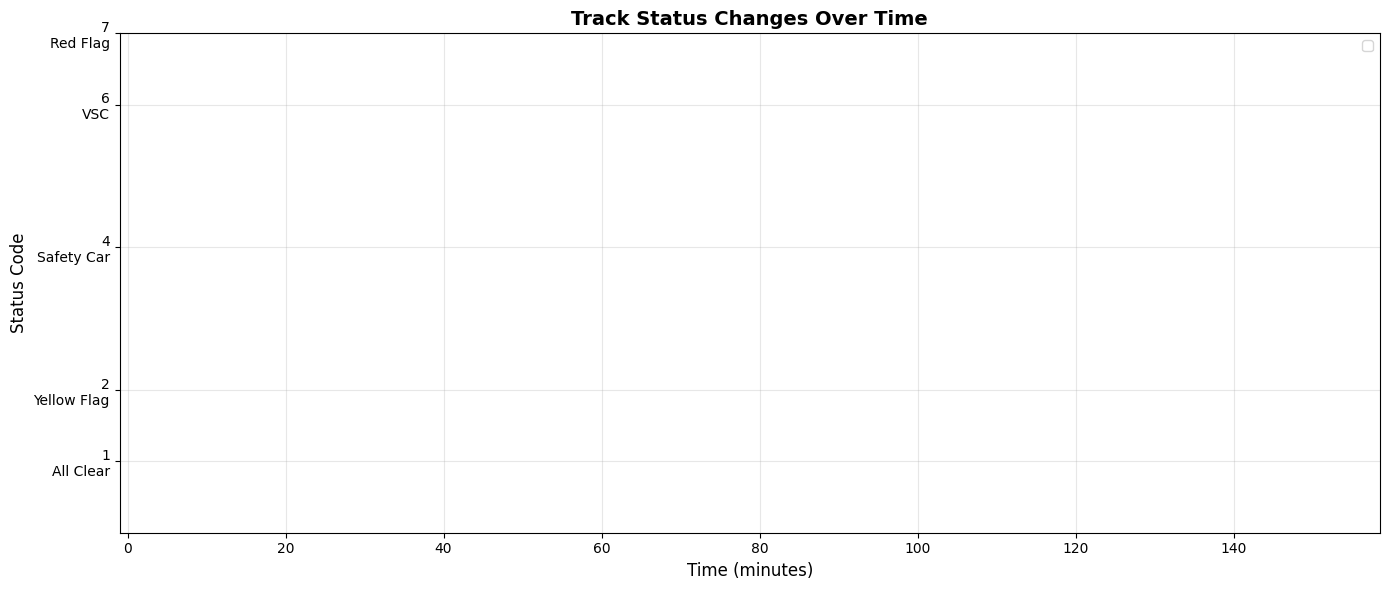

In [8]:
# Visualize track status over time
fig, ax = plt.subplots(figsize=(14, 6))

# Convert Time to minutes for better readability
time_minutes = session.track_status['Time'].dt.total_seconds() / 60

# Map status codes to colors and labels
status_map = {
    1: ('green', 'All Clear'),
    2: ('yellow', 'Yellow Flag'),
    4: ('orange', 'Safety Car'),
    6: ('blue', 'VSC'),
    7: ('red', 'Red Flag')
}

# Create a scatter plot with different colors for each status
for status_code, (color, label) in status_map.items():
    mask = session.track_status['Status'] == status_code
    if mask.any():
        ax.scatter(time_minutes[mask], session.track_status.loc[mask, 'Status'], 
                  color=color, label=label, s=100, alpha=0.7, marker='o')

ax.set_xlabel('Time (minutes)', fontsize=12)
ax.set_ylabel('Status Code', fontsize=12)
ax.set_title('Track Status Changes Over Time', fontsize=14, fontweight='bold')
ax.set_yticks(list(status_map.keys()))
ax.set_yticklabels([f"{code}\n{status_map[code][1]}" for code in status_map.keys()])
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, time_minutes.max() + 1)

plt.tight_layout()
plt.show()


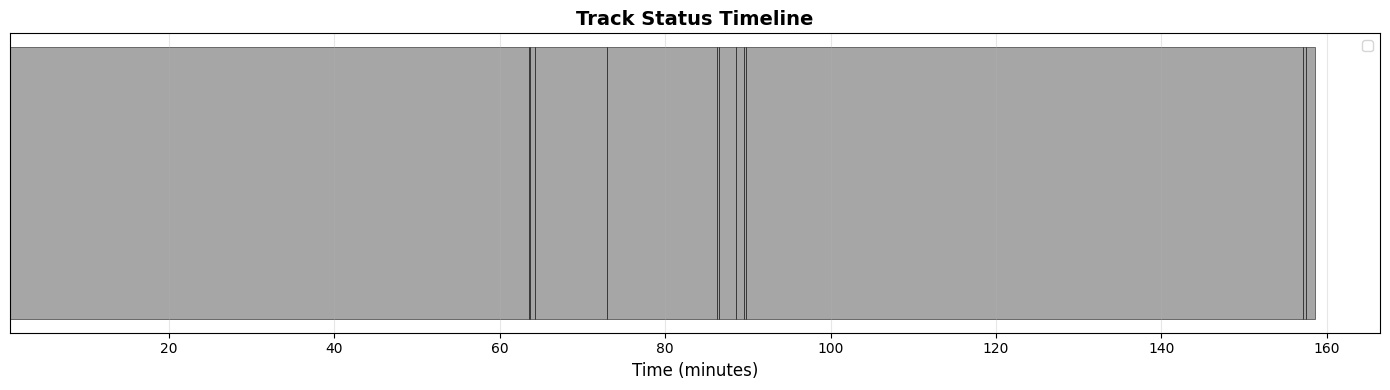

In [10]:
# Create a timeline visualization showing status periods
fig, ax = plt.subplots(figsize=(14, 4))

# Sort by time
df_sorted = session.track_status.sort_values('Time').copy()
time_minutes = df_sorted['Time'].dt.total_seconds() / 60

# Status mapping for colors and labels
status_map = {
    1: ('green', 'All Clear'),
    2: ('yellow', 'Yellow Flag'),
    4: ('orange', 'Safety Car'),
    6: ('blue', 'VSC'),
    7: ('red', 'Red Flag')
}
color_map = {code: color for code, (color, _) in status_map.items()}

# For each status change, create a horizontal bar
y_pos = 0
for i in range(len(df_sorted)):
    if i < len(df_sorted) - 1:
        duration = (df_sorted.iloc[i+1]['Time'] - df_sorted.iloc[i]['Time']).total_seconds() / 60
    else:
        duration = 1  # Last status continues
    
    status = df_sorted.iloc[i]['Status']
    color = color_map.get(status, 'gray')
    
    ax.barh(y_pos, duration, left=time_minutes.iloc[i], 
           color=color, alpha=0.7, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Time (minutes)', fontsize=12)
ax.set_ylabel('', fontsize=12)
ax.set_title('Track Status Timeline', fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[code], label=status_map[code][1]) 
                   for code in status_map.keys() if (df_sorted['Status'] == code).any()]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


## Practical Usage Examples

### 1. Filter out laps affected by Safety Car or VSC
```python
# Get all safety car and VSC periods
sc_vsc_periods = session.track_status[session.track_status['Status'].isin([4, 6])]

# Filter laps that occurred during these periods
# (This requires matching LapStartTime with track_status Time)
```

### 2. Identify when track status changed
```python
# Get all status changes
status_changes = session.track_status.sort_values('Time')

# Find when Safety Car was deployed
sc_deployed = session.track_status[session.track_status['Status'] == 4]['Time'].min()
```

### 3. Check if a specific lap time was affected
```python
# Determine track status at a given time
lap_time = pd.Timedelta(minutes=15, seconds=30)
status_at_time = session.track_status[session.track_status['Time'] <= lap_time]['Status'].iloc[-1]

if status_at_time in [4, 6, 2]:  # SC, VSC, or Yellow
    print("Lap was affected by track conditions")
```

### 4. Using track_status as features for ML models
- **Binary flags**: Was SC/VSC active? Were yellow flags out?
- **Status duration**: How long were flags/SC out?
- **Status changes**: Number of status changes (indicates eventful race)
- **Filtering**: Use to exclude invalid/slow laps from training data

### 5. Calculate time periods for each status
```python
# Calculate duration of each status period
df_sorted = session.track_status.sort_values('Time').copy()
df_sorted['Duration'] = df_sorted['Time'].diff().shift(-1)
df_sorted['Duration'] = df_sorted['Duration'].fillna(pd.Timedelta(0))

# Group by status and sum durations
status_durations = df_sorted.groupby('Status')['Duration'].sum()
```
